<a href="https://colab.research.google.com/github/nesher88/data-ai-world-cup-2026/blob/main/notebooks/01-messi-data-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to Deal with Messi Data 🐐🧹 — **Google Colab edition**

### Tracking data, event data, and the agents that clean up after both

Football data is **messy**. We expose three real gotchas in broadcast tracking,
reward ourselves with one beautiful Messi artifact from StatsBomb, then let three
small LLM agents do the boring 80% (diagnose → translate → red-team).

---
**What changed from the DataLab original (so it runs in Colab):**
1. **Secrets** are read from Colab's 🔑 sidebar (`google.colab.userdata`) instead of DataLab Environment Secrets — with a clean fallback so the notebook *never* errors mid-run.
2. **Data URLs** point at your forks by default (`nesher88/opendata` for SkillCorner tracking, `nesher88/open-data` for StatsBomb) and are one-line-switchable back to the upstream repos.
3. Small robustness fixes: `raise_for_status()` on fetches, an **LFS-pointer guard** (catches the classic "I got a 130-byte pointer instead of 89 MB" bug), and notes on the two quantities that quietly mislead (`minute` and `MATCHES_TO_LOAD`).

> Run cells **top to bottom**. The LLM sections are optional — without an API key they print pre-baked output.

## Step 0 · Setup & config

Colab ships pandas/numpy/matplotlib. We add `mplsoccer` (pitches + StatsBomb loader)
and the LLM SDKs. Then we set the knobs you might tweak live.

In [1]:
# One install for the whole notebook (quiet). ~30s on a fresh Colab runtime.
!pip install -q mplsoccer requests google-genai groq anthropic openai

import os, json, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Data source: your forks by default --------------------------------------
# SkillCorner broadcast tracking lives in your `opendata` fork.
# StatsBomb events live in your `open-data` fork (mirrors statsbomb/open-data).
GITHUB_OWNER = "nesher88"     # <- switch to "SkillCorner" to use the upstream tracking repo
SC_REPO      = "opendata"     # SkillCorner fork name

# ---- Knobs you might tweak live ----------------------------------------------
MATCH_ID        = 2017461     # SkillCorner: Melbourne V vs Auckland FC
SB_COMP_ID      = 11          # StatsBomb La Liga
SB_SEASON_ID    = 23          # 2011/12 -> Messi's 50-goal league season
MESSI           = "Lionel Andrés Messi Cuccittini"
#MATCHES_TO_LOAD = 12          # cap Barca matches for live speed.
MATCHES_TO_LOAD = None          # cap Barca matches for live speed.
                              #   NOTE: 12 != the full 38-game season, so goal/xG
                              #   totals below are a SAMPLE, not the famous 50.
                              #   Set to None to reproduce the full-season artifact.
MAX_FRAMES      = None        # cap tracking frames for speed; None = all (~71k)
DATA_DIR        = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Setup ready. Source repo:", f"{GITHUB_OWNER}/{SC_REPO}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 870.1/870.1 kB 8.7 MB/s eta 0:00:00
Setup ready. Source repo: nesher88/opendata


## Step 1 · Load the mess — SkillCorner broadcast tracking

Two gotchas before a single number comes out:

1. The tracking file is stored with **Git LFS**. The normal `raw.githubusercontent.com`
   URL returns a ~130-byte *pointer*, not the data — you must use
   **`media.githubusercontent.com/media/...`**. (We add a guard that catches this.)
2. Tracking `player_id` may key on the player's `id` **or** their `trackable_object`,
   so we index **both**, defensively.

In [2]:
BASE = f"https://raw.githubusercontent.com/{GITHUB_OWNER}/{SC_REPO}/master/data/matches"
LFS  = f"https://media.githubusercontent.com/media/{GITHUB_OWNER}/{SC_REPO}/master/data/matches"

# --- match metadata (a normal file: raw URL is fine) --------------------------
r = requests.get(f"{BASE}/{MATCH_ID}/{MATCH_ID}_match.json")
r.raise_for_status()
meta = r.json()

pitch_len, pitch_wid = meta["pitch_length"], meta["pitch_width"]
periods = {p["period"]: p for p in meta["match_periods"]}
print(f"{meta['home_team']['short_name']} vs {meta['away_team']['short_name']}"
      f"  |  pitch {pitch_len}x{pitch_wid}m")

# Build id -> (name, team). Index trackable_object AND id AND player_id (defensive).
id_to_name, id_to_team = {}, {}
team_name = {meta["home_team"]["id"]: meta["home_team"]["short_name"],
             meta["away_team"]["id"]: meta["away_team"]["short_name"]}
for pl in meta["players"]:
    nm = pl.get("short_name") or f"{pl.get('first_name','')} {pl.get('last_name','')}".strip()
    tm = team_name.get(pl.get("team_id"), "?")
    for key in (pl.get("trackable_object"), pl.get("id"), pl.get("player_id")):
        if key is not None:
            id_to_name[key] = nm
            id_to_team[key] = tm
print(f"{len(meta['players'])} players in lineup.")

Melbourne V FC vs Auckland FC  |  pitch 105x68m
36 players in lineup.


In [3]:
# --- download the LFS tracking file once (cached for this session) ------------
track_path = f"{DATA_DIR}/{MATCH_ID}_tracking.jsonl"

def looks_like_lfs_pointer(path, probe=200):
    with open(path, "rb") as fh:
        return fh.read(probe).startswith(b"version https://git-lfs")

if (not os.path.exists(track_path)) or looks_like_lfs_pointer(track_path):
    url = f"{LFS}/{MATCH_ID}/{MATCH_ID}_tracking_extrapolated.jsonl"
    print("Downloading ~89 MB tracking file ...")
    with requests.get(url, stream=True) as resp:
        resp.raise_for_status()
        with open(track_path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                f.write(chunk)

# Guard: if we still have a pointer, the media URL/owner is wrong — fail loudly.
assert not looks_like_lfs_pointer(track_path), (
    "Got a Git-LFS POINTER, not the data. Check GITHUB_OWNER and that you used the "
    "media.githubusercontent.com/media/... URL (not raw.githubusercontent.com).")

print("Tracking file ready:", track_path,
      f"({os.path.getsize(track_path)/1e6:.1f} MB)")

Tracking file ready: data/2017461_tracking.jsonl (89.5 MB)


In [4]:
# --- parse JSONL -> one tidy long row per (frame, player) ---------------------
# Each line is one frame: {frame, timestamp, period, ball_data, possession, player_data:[...]}
# Each player_data item:  {x, y, player_id, is_detected}
#   is_detected == False  =>  position is EXTRAPOLATED (a guess), not measured.
rows = []
with open(track_path) as f:
    for i, line in enumerate(f):
        if MAX_FRAMES and i >= MAX_FRAMES:
            break
        fr = json.loads(line)
        for p in fr.get("player_data", []):
            rows.append((fr.get("frame"), fr.get("period"),
                         p.get("player_id"), p.get("x"), p.get("y"),
                         bool(p.get("is_detected"))))

trk = pd.DataFrame(rows, columns=["frame", "period", "player_id", "x", "y", "is_detected"])

# NOTE: 10 fps. `minute` here is a FRAME-INDEX minute (it spans the whole broadcast,
# incl. the half-time gap), not a match-clock minute. Fine for coverage-over-time;
# don't read it as the official game clock.
trk["minute"] = trk["frame"] / 10 / 60
trk["name"]   = trk["player_id"].map(id_to_name).fillna("unmapped")
trk["team"]   = trk["player_id"].map(id_to_team).fillna("?")

print(f"{len(trk):,} player-frames | {trk.player_id.nunique()} tracked ids | "
      f"{(~trk.is_detected).mean():.0%} of positions are EXTRAPOLATED, not seen")
trk.head()

888,888 player-frames | 32 tracked ids | 49% of positions are EXTRAPOLATED, not seen


,frame,period,player_id,x,y,is_detected,minute,name,team
0,2510,1,51678,-38.16,1.51,False,4.183333,J. Duncan,Melbourne V FC
1,2510,1,51013,-20.78,3.31,True,4.183333,B. Hamill,Melbourne V FC
2,2510,1,51685,-20.93,14.81,True,4.183333,L. Jackson,Melbourne V FC
3,2510,1,800322,-21.03,-8.49,True,4.183333,J. Inserra,Melbourne V FC
4,2510,1,811820,-8.60,23.72,True,4.183333,K. Bos,Melbourne V FC


## Step 2 · Expose the mess (three real gotchas)

Everything below is a genuine property of broadcast tracking — not synthetic noise.

### 2.1 · Broadcast coverage gaps — the camera only sees so much
When the ball is on the right, the left-back is *guessed*. Watch the share of
genuinely-detected players rise and fall across the match.

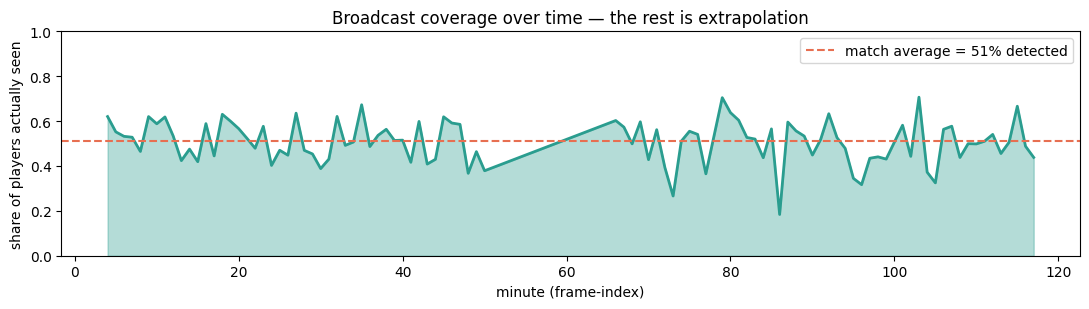

In [5]:
# Share of players actually DETECTED in each frame, then averaged per minute.
cov = trk.groupby("frame")["is_detected"].mean()
cov_min = cov.groupby((cov.index / 10 / 60).round().astype(int)).mean()

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.fill_between(cov_min.index, cov_min.values, color="#2a9d8f", alpha=.35)
ax.plot(cov_min.index, cov_min.values, color="#2a9d8f", lw=2)
ax.axhline(cov.mean(), ls="--", color="#e76f51",
           label=f"match average = {cov.mean():.0%} detected")
ax.set(xlabel="minute (frame-index)", ylabel="share of players actually seen",
       ylim=(0, 1), title="Broadcast coverage over time — the rest is extrapolation")
ax.legend(); plt.tight_layout(); plt.show()

### 2.2 · The disappearing player
Pick the most-tracked outfielder and watch them blink out every time the camera
looks elsewhere. *In broadcast tracking, even your star vanishes the moment the
ball leaves him.*

Following: L. Verstraete  (66% of his frames are actually seen)


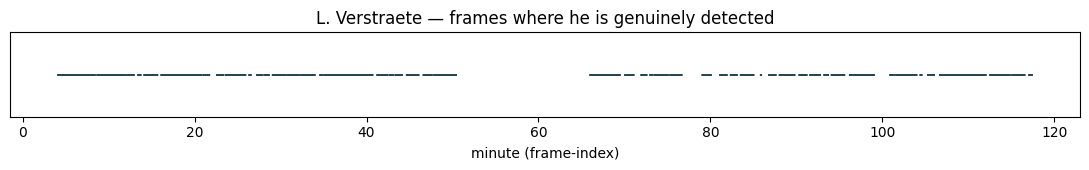

In [6]:
# The most-frequently-DETECTED player id.
star_id = trk[trk.is_detected].player_id.value_counts().idxmax()
star    = trk[trk.player_id == star_id].sort_values("frame")
print(f"Following: {id_to_name.get(star_id, star_id)}  "
      f"({star.is_detected.mean():.0%} of his frames are actually seen)")

fig, ax = plt.subplots(figsize=(11, 1.8))
seen = star[star.is_detected]
ax.scatter(seen.minute, [1] * len(seen), s=4, color="#264653", marker="|")
ax.set(yticks=[], xlabel="minute (frame-index)",
       title=f"{id_to_name.get(star_id, star_id)} — frames where he is genuinely detected")
plt.tight_layout(); plt.show()

### 2.3 · The half-time direction flip
Teams switch ends at half-time, but the raw coordinate system doesn't. The classic
check is to average a team's `x` per half — yet here's the catch most people miss.

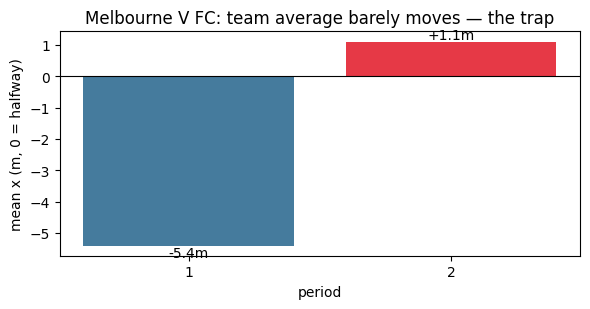

In [7]:
# BEAT 1 (the trap): a whole team's centroid sits near halfway, so the end-switch
# mostly CANCELS in the team average. It looks like nothing happened.
home = team_name[meta["home_team"]["id"]]
h = trk[(trk.team == home) & (trk.is_detected)]
flip = h.groupby("period")["x"].mean()

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(flip.index.astype(str), flip.values,
       color=["#457b9d" if v < 0 else "#e63946" for v in flip.values])
ax.axhline(0, color="k", lw=.8)
ax.set(xlabel="period", ylabel="mean x (m, 0 = halfway)",
       title=f"{home}: team average barely moves — the trap")
for p, v in flip.items():
    ax.text(str(p), v, f"{v:+.1f}m", ha="center", va="bottom" if v >= 0 else "top")
plt.tight_layout(); plt.show()

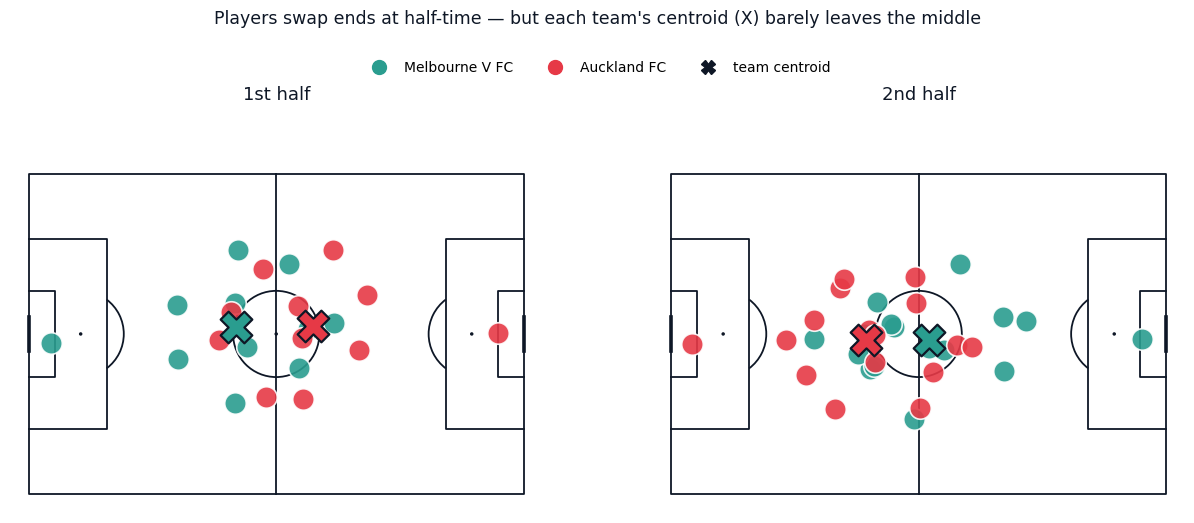

In [8]:
# BEAT 1 on a pitch: each team's average player positions clearly swap ends between
# halves, yet each team's CENTROID (the X) barely leaves the middle — which is all a
# 1-D "mean x per half" can see.
from mplsoccer import Pitch

pos = (trk[trk.is_detected]
       .groupby(["team", "period", "name"])[["x", "y"]].mean().reset_index())
PL, PW = meta["pitch_length"], meta["pitch_width"]
home = team_name[meta["home_team"]["id"]]
away = team_name[meta["away_team"]["id"]]
colors = {home: "#2a9d8f", away: "#e63946"}

pitch = Pitch(pitch_type="custom", pitch_length=PL, pitch_width=PW,
              line_color="#0E1726", linewidth=1.3, pad_top=14)
fig, axs = pitch.draw(nrows=1, ncols=2, figsize=(13, 4.8))
for ax, period in zip(axs, [1, 2]):
    half = pos[pos.period == period]
    for team, col in colors.items():
        t = half[half.team == team]
        X, Y = t.x + PL / 2, t.y + PW / 2            # centre-origin -> corner-origin
        pitch.scatter(X, Y, ax=ax, s=240, color=col, edgecolors="white",
                      linewidth=1.2, alpha=.9, zorder=3)
        pitch.scatter(X.mean(), Y.mean(), ax=ax, s=520, marker="X", color=col,
                      edgecolors="#0E1726", linewidth=1.6, zorder=4)   # centroid
    ax.set_title(f"{'1st' if period == 1 else '2nd'} half", fontsize=13, color="#0E1726")

import matplotlib.lines as mlines
handles = [mlines.Line2D([], [], marker="o", ls="", color=c, markersize=10, label=t)
           for t, c in colors.items()]
handles.append(mlines.Line2D([], [], marker="X", ls="", color="#0E1726", markersize=10,
                             label="team centroid"))
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Players swap ends at half-time — but each team's centroid (X) barely "
             "leaves the middle", y=1.08, fontsize=12.5, color="#0E1726")
plt.tight_layout(); plt.show()

**But every individual flips.** Average *per player* instead and plot 1st-half mean
`x` against 2nd-half mean `x`. If points hug the `y = −x` line, ends genuinely switch
in the raw coordinates and you must flip one half before any positional analysis. If
they hug `y = +x`, the feed is already pre-oriented and you must **not** flip.

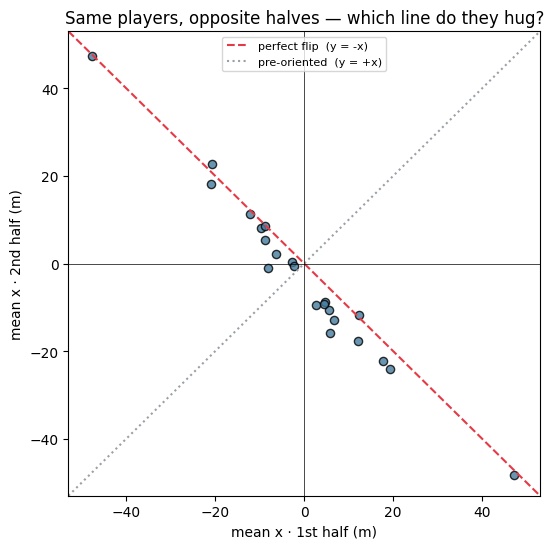

In [9]:
# BEAT 2 (per player): each dot is one player's mean x in each half.
det = trk[trk.is_detected]
pp = (det.pivot_table(index="name", columns="period", values="x", aggfunc="mean")
         .dropna())                       # keep players seen in both halves
lim = float(np.nanmax(np.abs(pp[[1, 2]].values))) * 1.1

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.scatter(pp[1], pp[2], s=35, color="#457b9d", edgecolor="k", alpha=.8)
ax.plot([-lim, lim], [lim, -lim], ls="--", color="#e63946", label="perfect flip  (y = -x)")
ax.plot([-lim, lim], [-lim, lim], ls=":", color="#9aa0a6", label="pre-oriented  (y = +x)")
ax.axhline(0, color="k", lw=.5); ax.axvline(0, color="k", lw=.5)
ax.set(xlim=(-lim, lim), ylim=(-lim, lim),
       xlabel="mean x · 1st half (m)", ylabel="mean x · 2nd half (m)",
       title="Same players, opposite halves — which line do they hug?")
ax.legend(loc="upper center", fontsize=8); plt.tight_layout(); plt.show()

> **Three more you'll meet in real Week-1 work** (not coded here): syncing events to
tracking via `frame_start`, reconciling the ~3% of imperfect player identities, and
smoothing the raw speed/acceleration signal. That's the unglamorous craft.

## Step 3 · The payoff — one beautiful Messi artifact (StatsBomb)

The reward for caring about data quality: a recognizable picture of the best season
a forward has ever had. `mplsoccer.Sbopen` pulls StatsBomb's open data from GitHub.

> `Sbopen()` reads the canonical `statsbomb/open-data` (identical to your `open-data`
> fork). If you ever want to force your fork, you can fetch the JSON yourself from
> `https://raw.githubusercontent.com/{GITHUB_OWNER}/open-data/master/data/...` — but
> the loader below is the path of least resistance and gives the same numbers.

**Reminder:** with `MATCHES_TO_LOAD = 12` these totals are a *sample*. Set it to
`None` in Step 0 to reproduce the full-season ~50-goal artifact.

In [10]:
from mplsoccer import Sbopen, VerticalPitch
sb = Sbopen()

matches = sb.match(competition_id=SB_COMP_ID, season_id=SB_SEASON_ID)
barca   = matches[(matches.home_team_name == "Barcelona") |
                  (matches.away_team_name == "Barcelona")]
ids = barca.match_id.tolist()
if MATCHES_TO_LOAD:
    ids = ids[:MATCHES_TO_LOAD]

shots = []
for mid in ids:                       # one event() call per match
    ev, *_ = sb.event(mid)
    shots.append(ev[(ev.type_name == "Shot") & (ev.player_name == MESSI)])
shots = pd.concat(shots, ignore_index=True)
goals = shots[shots.outcome_name == "Goal"]

xg = shots.shot_statsbomb_xg.sum()
print(f"Messi · La Liga 2011/12 · {len(ids)} matches loaded")
print(f"  shots {len(shots)} | goals {len(goals)} | xG {xg:.1f} | "
      f"finishing (G-xG) {len(goals)-xg:+.1f}")

Messi · La Liga 2011/12 · 37 matches loaded
  shots 198 | goals 50 | xG 35.7 | finishing (G-xG) +14.3


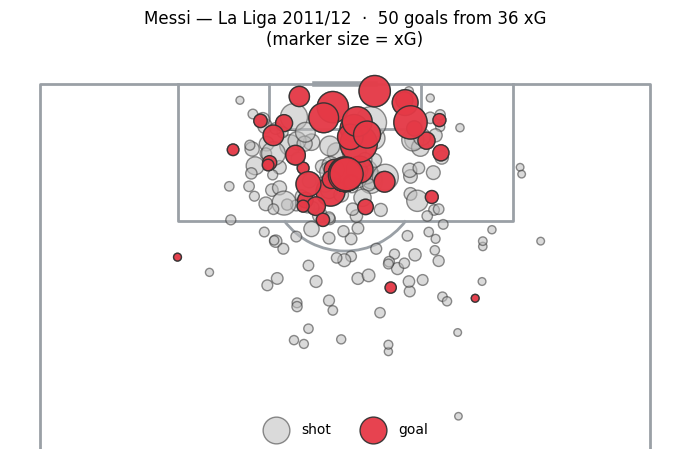

In [11]:
pitch = VerticalPitch(pitch_type="statsbomb", half=True, pad_bottom=-12,
                      line_color="#9aa0a6")
fig, ax = pitch.draw(figsize=(7, 7))
pitch.scatter(shots.x, shots.y, ax=ax, c="#bdbdbd", edgecolors="#333",
              s=shots.shot_statsbomb_xg * 700 + 25, alpha=.55, label="shot")
pitch.scatter(goals.x, goals.y, ax=ax, c="#e63946", edgecolors="#333",
              s=goals.shot_statsbomb_xg * 700 + 25, alpha=.95, label="goal")
ax.set_title(f"Messi — La Liga 2011/12  ·  {len(goals)} goals from {xg:.0f} xG\n"
             "(marker size = xG)", fontsize=12)
ax.legend(loc="lower center", ncol=2, frameon=False)
plt.tight_layout(); plt.show()

## Step 4 · The LLM plumbing — Colab secrets + a bulletproof `call_llm`

We hand a *profile* of the data to an agent and let it diagnose + write cleaning code.

**Colab secrets:** open the 🔑 (key) icon in the left sidebar, add a secret named for
your provider (e.g. `GEMINI_API_KEY`), and toggle *Notebook access* on. Gemini (Google
AI Studio) and Groq both issue **free** keys — no Anthropic billing needed. With no key,
every agent cell prints pre-baked output, so the notebook never errors mid-run.

In [12]:
# Pick a provider. Free keys: "gemini" (aistudio.google.com) or "groq" (console.groq.com).
PROVIDER = "openai"     # "gemini" | "groq" | "anthropic" | "openai"

PROVIDER_CFG = {                        # (secret name, default model — swap freely)
    "gemini":    ("GEMINI_API_KEY",    "gemini-2.0-flash"),
    "groq":      ("GROQ_API_KEY",      "llama-3.3-70b-versatile"),
    "anthropic": ("ANTHROPIC_API_KEY", "claude-sonnet-4-6"),
    "openai":    ("OPENAI_API_KEY",    "gpt-4o-mini"),
}
KEY_ENV, MODEL = PROVIDER_CFG[PROVIDER]

def get_secret(name):
    """Read a key from Colab's Secrets sidebar, falling back to env vars."""
    try:
        from google.colab import userdata
        val = userdata.get(name)
        if val:
            return val
    except Exception:
        pass
    return os.environ.get(name)

def call_llm(system, user, fallback=""):
    """Call the chosen provider; fall back to pre-baked text if no key or the call fails.
    The fallback is what makes a live demo bulletproof — it never errors mid-session."""
    key = get_secret(KEY_ENV)
    if not key:
        print(f"(no {KEY_ENV} found in Colab Secrets — showing cached output)\n")
        return fallback
    try:
        if PROVIDER == "gemini":
            from google import genai
            r = genai.Client(api_key=key).models.generate_content(
                model=MODEL, contents=user, config={"system_instruction": system})
            return r.text
        if PROVIDER == "groq":
            from groq import Groq
            r = Groq(api_key=key).chat.completions.create(model=MODEL,
                messages=[{"role": "system", "content": system},
                          {"role": "user", "content": user}])
            return r.choices[0].message.content
        if PROVIDER == "anthropic":
            from anthropic import Anthropic
            m = Anthropic(api_key=key).messages.create(model=MODEL, max_tokens=1400,
                system=system, messages=[{"role": "user", "content": user}])
            return "".join(b.text for b in m.content if b.type == "text")
        if PROVIDER == "openai":
            from openai import OpenAI
            r = OpenAI(api_key=key).chat.completions.create(model=MODEL,
                messages=[{"role": "system", "content": system},
                          {"role": "user", "content": user}])
            return r.choices[0].message.content
    except Exception as e:
        print(f"(live call failed: {e} — showing cached output)\n")
        return fallback

# Tip: run once with your key, then paste the REAL output into the fallback strings
# below so your offline demo is identical to the live one.

## Step 5 · Agent #1 — the Data-Janitor 🧹

We just diagnosed the tracking mess by hand. Now we hand a *profile* of the data to an
agent and let it rank the issues and write the cleaning code.

In [13]:
def profile_df(df):
    return (
        f"shape: {df.shape[0]} rows x {df.shape[1]} cols\n"
        f"columns/dtypes:\n{df.dtypes.to_string()}\n\n"
        f"extrapolated (is_detected==False): {(~df.is_detected).mean():.1%} of rows\n"
        f"unmapped player ids: {(df.name=='unmapped').mean():.1%} of rows\n"
        f"unique player_ids: {df.player_id.nunique()}\n"
        f"x range: [{df.x.min():.1f}, {df.x.max():.1f}] | "
        f"y range: [{df.y.min():.1f}, {df.y.max():.1f}]\n"
        f"mean x by period:\n{df[df.is_detected].groupby('period').x.mean().to_string()}\n\n"
        f"sample rows:\n{df.head(4).to_string(index=False)}"
    )

JANITOR_SYSTEM = (
    "You are a meticulous football tracking-data engineer. You are given a profile of a "
    "BROADCAST tracking dataframe (positions are computer-vision derived; off-camera players "
    "are extrapolated, not measured). Be concrete and football-aware. Respond in three short "
    "sections:\n"
    "1) ISSUES — ranked by severity, each one line, citing the evidence in the profile.\n"
    "2) CLEANING — runnable pandas snippets that fix or flag each issue (assume the df is `trk`).\n"
    "3) DO-NOT — one sentence on the tempting fix that would actually corrupt the analysis.\n"
    "Never invent columns that aren't in the profile."
)

pm = trk[trk.is_detected].groupby("period").x.mean()
p1, p2 = pm.get(1, float("nan")), pm.get(2, float("nan"))
unmapped = (trk.name == "unmapped").mean()
id_line = (
    f" - {unmapped:.0%} of rows have an unresolved id: broadcast id switches leak aggregates across players.\n"
    if unmapped > 0.01 else
    " - ids resolved cleanly here (0% unmapped), but expect ~3% identity error in general — re-check every match.\n"
)
janitor_fallback = (
"1) ISSUES (ranked)\n"
f" - {(~trk.is_detected).mean():.0%} of positions are EXTRAPOLATED, not measured: per-frame speed/distance/spacing is part-fiction unless you filter on is_detected.\n"
f" - team-average x barely moves between halves ({p1:+.1f}m -> {p2:+.1f}m) — that's the TRAP, not the all-clear: the end-switch cancels at team level. Confirm per player before deciding whether to flip.\n"
+ id_line +
" - raw x/y carry computer-vision jitter; frame-to-frame speed will be spiky and overstated.\n\n"
"2) CLEANING\n"
" # only flip if the per-player chart (2.3) shows points on y = -x; if y = +x, the feed is pre-oriented — skip this line\n"
" trk.loc[trk.period == 2, ['x','y']] *= -1\n"
" clean = trk[(trk.is_detected) & (trk.name != 'unmapped')].copy()\n"
" clean = clean.sort_values(['player_id','frame'])\n"
" clean[['x','y']] = (clean.groupby('player_id')[['x','y']]\n"
"                          .transform(lambda s: s.rolling(5, center=True, min_periods=1).mean()))\n\n"
"3) DO-NOT\n"
" Don't interpolate across extrapolated gaps and then compute distance covered: you'd be measuring the tracker's guesses, not the player."
)

print(call_llm(JANITOR_SYSTEM,
               "Here is the profile of my tracking dataframe `trk`:\n\n" + profile_df(trk),
               fallback=janitor_fallback))

### ISSUES
1. **High Percentage of Extrapolated Data**: Nearly 49% of rows have `is_detected` set to False, which raises concern over data quality and reliability.
2. **Negative x and y Coordinates**: The x and y coordinate ranges indicate neighborhoods that are potentially outside the valid field dimensions (typically x should range from 0 to 120 and y from 0 to 80 for an American football field).
3. **Mean x Values by Period**: The mean x values are significantly negative across both periods, suggesting issues with player positioning or detection throughout the game.

### CLEANING
```python
# Flag for extrapolated players (for potential examination)
extrapolated_flag = trk['is_detected'] == False

# Ensure there are no players detected outside a realistic field boundary (assuming a standard field layout)
valid_field = trk[(trk['x'] >= 0) & (trk['x'] <= 120) & (trk['y'] >= 0) & (trk['y'] <= 80)]

# Investigate and handle negative mean x values
mean_x_by_period = trk.groupby('period')[

## Step 6 · Agent #2 — the Wordalisation agent ✍️

A shot map is useless to a coach mid-week or a sporting director in a contract meeting
*unless someone translates it*. This agent turns the **same numbers** into the **three
registers a club actually uses**.

In [14]:
messi_stats = (
    f"Player: Lionel Messi\n"
    f"Competition/season: La Liga 2011/12 ({len(ids)} matches in sample)\n"
    f"Shots: {len(shots)}\n"
    f"Goals: {len(goals)}\n"
    f"Total xG: {xg:.1f}\n"
    f"Finishing (Goals minus xG): {len(goals)-xg:+.1f}\n"
    f"Goals per match: {len(goals)/len(ids):.2f}\n"
    f"Avg xG per shot: {shots.shot_statsbomb_xg.mean():.3f}\n"
    f"Share of shots from inside the box (x>102): {(shots.x>102).mean():.0%}"
)

WORDALISER_SYSTEM = (
    "You are a football analytics writer. You convert a block of model outputs into THREE "
    "registers, each ~3 sentences, clearly labelled:\n"
    "• COACH — present tense, tactical, what to reinforce or exploit this week.\n"
    "• SCOUT — comparative, recruitment lens, what the profile signals about the player type.\n"
    "• SPORTING DIRECTOR — value/risk framing for a boardroom decision.\n"
    "Use ONLY the numbers provided. Do not invent stats, opponents, or events. If the finishing "
    "figure is strongly positive, treat it as evidence of elite finishing relative to chance quality."
)

fin = len(goals) - xg
gpm = len(goals) / len(ids)
word_fallback = (
f"COACH - Across these {len(ids)} matches Messi takes {len(shots)} shots for {len(goals)} goals, "
f"almost all from inside the box, finishing {fin:+.1f} above the {xg:.1f} xG those chances were worth. "
"The plan works: get him the ball in central box areas and trust the finish; reinforce the patterns "
"that manufacture those high-value looks.\n\n"
f"SCOUT - An elite, high-volume penalty-box finisher: {shots.shot_statsbomb_xg.mean():.2f} xG per shot "
"with strongly positive goals-over-expected. This is a primary scorer to build an attack around, not a "
"volume-from-distance shooter.\n\n"
f"SPORTING DIRECTOR - {len(goals)} goals at {gpm:.2f} per game from {xg:.1f} expected is point-winning, "
"shirt-selling production, and the premium over xG reads as repeatable skill rather than variance on this "
"sample. The flip side is concentration risk: this much output through one player is a dependency to price "
"into squad planning and contract decisions."
)

print(call_llm(WORDALISER_SYSTEM,
               "Translate these outputs into the three registers:\n\n" + messi_stats,
               fallback=word_fallback))

**COACH:** This week, we need to focus on maximizing our opportunities in the final third, particularly leveraging positions inside the box where we know we can create high-quality chances. Given Messi's outstanding ability to finish, we should encourage players to look for him in goal-scoring positions, emphasizing quick transitions and precise passing to exploit defenses. Reinforcing our movements off the ball will be crucial to ensure he receives shots in optimal areas, which could lead to a significant number of goals.

**SCOUT:** Messi's profile showcases an elite goal scorer with an exceptional finishing ability, markedly outperforming expected goals by over +14.3. His 1.35 goals per match and a remarkable conversion rate suggest that he thrives in creating high-quality scoring opportunities, especially with 70% of his shots taken from inside the box. This strongly signals a player who not only has the skill but also an instinct for goal, making him valuable for any team seeking 

## Step 7 · Agent #3 — the Critic 🔍 *(agents that argue back)*

The first two agents *produced*. This one *pushes back*. We hand it our headline finding
and ask it to red-team the claim — *"is that real, or is it penalties / one lucky season?"*

In [15]:
# The obvious first attack on any "great finisher" claim: strip out penalties.
pen = shots[shots.sub_type_name == "Penalty"]
op  = shots[shots.sub_type_name != "Penalty"]
op_fin = (op.outcome_name == "Goal").sum() - op.shot_statsbomb_xg.sum()
n_fk = int((shots.sub_type_name == "Free Kick").sum())

claim_evidence = (
    f"CLAIM: Messi is an elite finisher — he scored {len(goals)} goals from {xg:.1f} xG, "
    f"so +{len(goals)-xg:.1f} over expectation.\n\n"
    f"EVIDENCE:\n"
    f"- Sample: La Liga 2011/12, {len(ids)} matches, {len(shots)} shots.\n"
    f"- Penalties: {len(pen)} shots, {(pen.outcome_name=='Goal').sum()} scored, {pen.shot_statsbomb_xg.sum():.1f} xG.\n"
    f"- Excluding penalties: {len(op)} shots, {(op.outcome_name=='Goal').sum()} goals, "
    f"{op.shot_statsbomb_xg.sum():.1f} xG (finishing {op_fin:+.1f}).\n"
    f"- Free kicks among shots: {n_fk}.\n"
    f"- xG source: StatsBomb open data (single model, single season)."
)

CRITIC_SYSTEM = (
    "You are a skeptical, football-aware analytics reviewer — 'reviewer 2' crossed with a Head of "
    "Research. You are given a CLAIM and its EVIDENCE. Red-team it; do not just agree. Respond in three "
    "short sections:\n"
    "1) CONCERNS — ranked: is the effect real, or inflated by penalties / selection / a single season? "
    "note xG-model blind spots and anything that would shrink the gap.\n"
    "2) VERDICT — does the claim survive? be specific and quantitative using the numbers given.\n"
    "3) NEXT CHECKS — the 2-3 things that would most strengthen or refute it.\n"
    "Use only the numbers provided. Be concrete and willing to say what is genuinely robust."
)

critic_fallback = (
"1) CONCERNS (ranked)\n"
f" - Penalty inflation? {len(pen)} of {len(shots)} shots are penalties "
f"({(pen.outcome_name=='Goal').sum()} scored, {pen.shot_statsbomb_xg.sum():.1f} xG). But strip them and "
f"finishing is still {op_fin:+.1f} over {op.shot_statsbomb_xg.sum():.1f} xG from {len(op)} shots — so the gap is NOT mainly penalties.\n"
f" - Single season: {len(ids)} matches is a real but limited sample, and finishing-over-expected is the "
"metric that regresses hardest to the mean across seasons. One year is evidence, not proof.\n"
" - xG-model blind spots: StatsBomb xG can't see everything (keeper position, pressure). Part of any "
"over-performance is genuine skill, part is what the model simply can't measure.\n"
f" - Set pieces: {n_fk} shots are free kicks — low-xG attempts that can swing the headline gap; report them separately.\n\n"
"2) VERDICT\n"
f" Holds up. Even excluding penalties, {op_fin:+.0f} goals over expected from open play and set pieces is an "
"exceptional, not lucky, signal — though the precise magnitude will regress.\n\n"
"3) NEXT CHECKS\n"
" - Put a confidence interval on goals-minus-xG by simulating outcomes from each shot's xG.\n"
" - Benchmark against other elite finishers in the same season to calibrate 'exceptional'.\n"
" - Repeat across 3+ seasons to test repeatability."
)

print(call_llm(CRITIC_SYSTEM, claim_evidence, fallback=critic_fallback))

### CONCERNS
1. **Sample Size and Context**: This is based on a single season (2011/12), which may not be representative of Messi's overall finishing ability. Player performance can fluctuate based on context, surrounding teammates, and tactical changes over seasons. Reliance on one season could inflate the perceived effect.
   
2. **Penalty Influence**: While Messi scored 50 goals with a significant portion coming from penalties (10 out of 50), the penalties accounted for a substantial xG value (8.6). Separating penalties from field goals is essential. His non-penalty finishing (+13) is still impressive, but we must highlight the considerable impact penalties have on total goal tallies.

3. **xG Model Limitations**: The StatsBomb xG model used might have biases or limitations that do not capture all variables that impact goal-scoring opportunities (e.g., shot difficulty or goalkeeper quality). Certain factors influencing finishing quality may be understated.

### VERDICT
The claim tha

## Recap — the whole loop in one notebook

| Step | What you did |
|---|---|
| 1 | Parsed Git-LFS broadcast tracking into a tidy `(frame, player)` frame |
| 2 | Exposed three real gotchas: coverage gaps, the disappearing star, the half-time flip trap |
| 3 | Earned one clean StatsBomb shot-map artifact |
| 4–7 | Three agents: **diagnose** the mess → **translate** the numbers → **red-team** the claim |

**To go further:** set `MATCHES_TO_LOAD = None` (full season), add a real API key in the
🔑 sidebar, and try swapping `PROVIDER` between gemini / groq / anthropic to compare how
each agent reasons about the same evidence.